In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
from pylab import *

In [6]:
'''
Create vegetation land masks
'''
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

box = [(32,55),(232,256)]

def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


In [16]:
start,end = ('1984','2014')

# get d4PDF data
era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
Ant_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_Ant_ensMean.nc')
Nat_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc')
noise_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_all_and_nat_ensMean.nc')

noise_da = noise_da.sel(time=slice(start,end))

Ant_da = Ant_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Ant_da = Ant_da.sel(time=slice(start,end))
Ant_da = Ant_da.where(d4pdf_vege_mask>0)
Ant_da = Ant_da.where(~era5_da.isnull())

Nat_da = Nat_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Nat_da = Nat_da.sel(time=slice(start,end))
Nat_da = Nat_da.where(d4pdf_vege_mask>0)
Nat_da = Nat_da.where(~era5_da.isnull())

d4PDF_array = [Ant_da, Nat_da, noise_da]

# get CAM5 data
era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
Ant_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Ant_ensMean.nc')
Nat_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc')
noise_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_all_and_nat_ensMean.nc')

noise_da = noise_da.sel(time=slice(start,end))

Ant_da = Ant_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Ant_da = Ant_da.sel(time=slice(start,end))
Ant_da = Ant_da.where(cam5_vege_mask>0)
Ant_da = Ant_da.where(~era5_da.isnull())

Nat_da = Nat_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Nat_da = Nat_da.sel(time=slice(start,end))
Nat_da = Nat_da.where(cam5_vege_mask>0)
Nat_da = Nat_da.where(~era5_da.isnull())

CAM5_array = [Ant_da, Nat_da, noise_da]

/tmp/ipykernel_132326/1410291590.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('RdBu_r', 15)


Text(0.5, 1.0, 'Mean Noise')

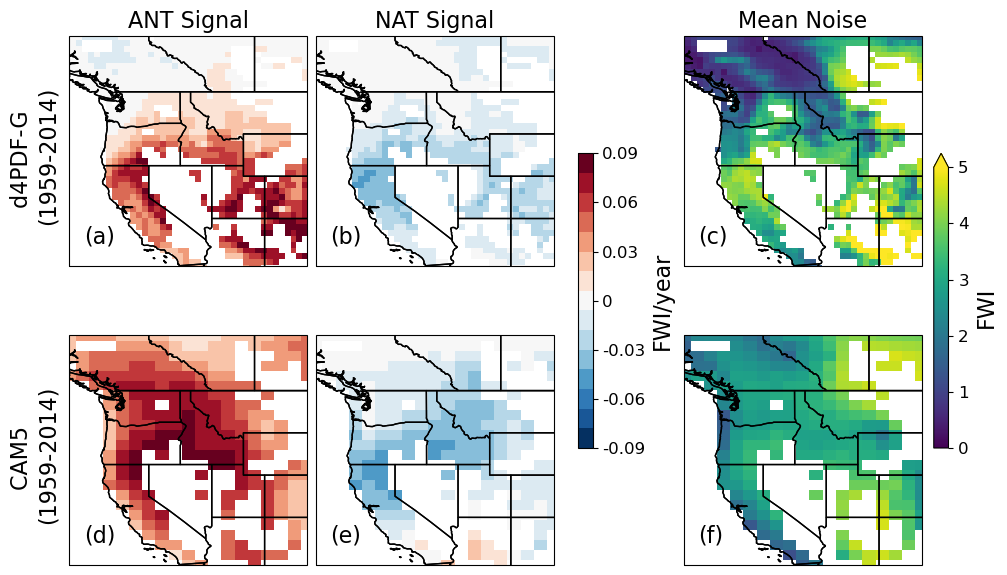

In [15]:
fig,axs = plt.subplots(2,3,figsize=(10,6),layout='constrained',subplot_kw=dict(projection=ccrs.PlateCarree()))

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

cmap = cm.get_cmap('RdBu_r', 15)

ant_im = xr.apply_ufunc(get_linregress_slope, d4PDF_array[0], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0][0],transform=ccrs.PlateCarree(),cmap=cmap,vmin=-0.09,vmax=0.09,add_colorbar=False)
nat_im = xr.apply_ufunc(get_linregress_slope, d4PDF_array[1], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0][1],transform=ccrs.PlateCarree(),cmap=cmap,vmin=-0.09,vmax=0.09,add_colorbar=False)
noise_im = d4PDF_array[2].mean('time').plot(ax=axs[0][2],transform=ccrs.PlateCarree(),cmap='viridis',vmin=0,vmax=5,add_colorbar=False)

ant_im = xr.apply_ufunc(get_linregress_slope, CAM5_array[0], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[1][0],transform=ccrs.PlateCarree(),cmap=cmap,vmin=-0.09,vmax=0.09,add_colorbar=False)
nat_im = xr.apply_ufunc(get_linregress_slope, CAM5_array[1], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[1][1],transform=ccrs.PlateCarree(),cmap=cmap,vmin=-0.09,vmax=0.09,add_colorbar=False)
noise_im = CAM5_array[2].mean('time').plot(ax=axs[1][2],transform=ccrs.PlateCarree(),cmap='viridis',vmin=0,vmax=5,add_colorbar=False)

cb = fig.colorbar(ant_im, ax=axs[0:2, 0:2], shrink=0.5,orientation='vertical')
cb.set_label(label='FWI/year',fontdict=font)
cb.set_ticks([-0.09,-0.06,-0.03,0,0.03,0.06,0.09])
font['size']=12
cb.set_ticklabels(['-0.09','-0.06','-0.03','0','0.03','0.06','0.09'],fontdict=font)
font['size']=16

cb = fig.colorbar(noise_im, ax=axs[0:2, 2], shrink=0.5,orientation='vertical',extend='max')
cb.set_label(label='FWI',fontdict=font)
cb.set_ticks([0,1,2,3,4,5])
font['size']=12
cb.set_ticklabels(['0','1','2','3','4','5'],fontdict=font)
font['size']=16

labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)']
for i,ax in enumerate(axs.flatten()):
    ax.coastlines()
    ax.add_feature(cf.BORDERS)
    ax.add_feature(cf.STATES)
    ax.set_extent([232.5,255, 32.5,54.18])
    
    ax.text(0.06,0.1,labels[i],transform=ax.transAxes,fontdict=font)

axs[0][0].text(-0.25,0.2,'d4PDF-G \n(1959-2014)',fontdict=font,transform=axs[0][0].transAxes, rotation='vertical',ma='center')
axs[1][0].text(-0.25,0.2,'CAM5 \n(1959-2014)',fontdict=font,transform=axs[1][0].transAxes, rotation='vertical',ma='center')

axs[0][0].set_title('ANT Signal',fontdict=font)
axs[0][1].set_title('NAT Signal',fontdict=font)
axs[0][2].set_title('Mean Noise',fontdict=font)

#plt.savefig(f'/home/queenle/fire_attribution/figures/sup_mat/SM_Fig11.png',dpi=300)


/tmp/ipykernel_132326/3504807237.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('RdBu_r', 15)


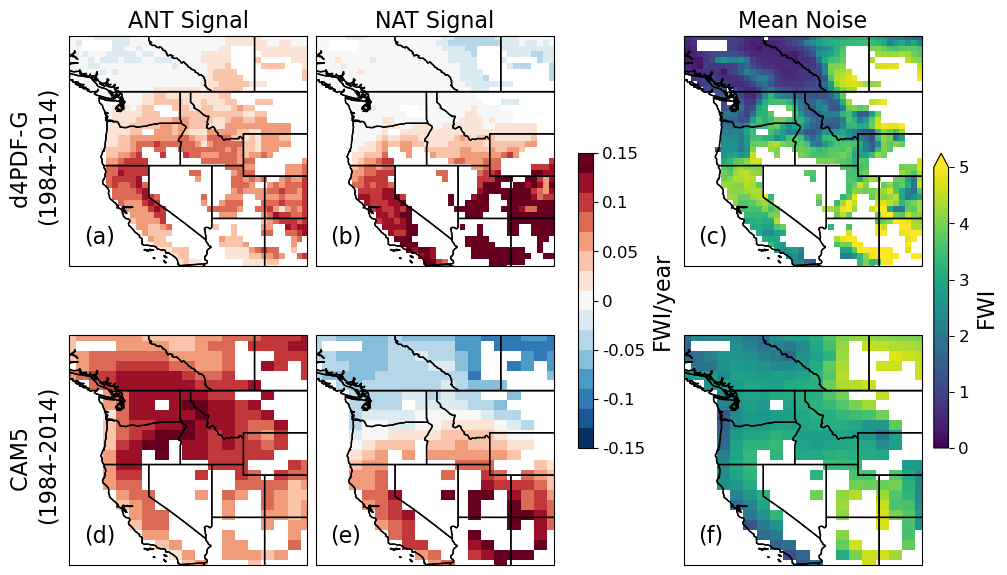

In [18]:
fig,axs = plt.subplots(2,3,figsize=(10,6),layout='constrained',subplot_kw=dict(projection=ccrs.PlateCarree()))

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

cmap = cm.get_cmap('RdBu_r', 15)

ant_im = xr.apply_ufunc(get_linregress_slope, d4PDF_array[0], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0][0],transform=ccrs.PlateCarree(),cmap=cmap,vmin=-0.15,vmax=0.15,add_colorbar=False)
nat_im = xr.apply_ufunc(get_linregress_slope, d4PDF_array[1], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0][1],transform=ccrs.PlateCarree(),cmap=cmap,vmin=-0.15,vmax=0.15,add_colorbar=False)
noise_im = d4PDF_array[2].mean('time').plot(ax=axs[0][2],transform=ccrs.PlateCarree(),cmap='viridis',vmin=0,vmax=5,add_colorbar=False)

ant_im = xr.apply_ufunc(get_linregress_slope, CAM5_array[0], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[1][0],transform=ccrs.PlateCarree(),cmap=cmap,vmin=-0.15,vmax=0.15,add_colorbar=False)
nat_im = xr.apply_ufunc(get_linregress_slope, CAM5_array[1], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[1][1],transform=ccrs.PlateCarree(),cmap=cmap,vmin=-0.15,vmax=0.15,add_colorbar=False)
noise_im = CAM5_array[2].mean('time').plot(ax=axs[1][2],transform=ccrs.PlateCarree(),cmap='viridis',vmin=0,vmax=5,add_colorbar=False)

cb = fig.colorbar(ant_im, ax=axs[0:2, 0:2], shrink=0.5,orientation='vertical')
cb.set_label(label='FWI/year',fontdict=font)
cb.set_ticks([-0.15,-0.1,-0.05,0,0.05,0.1,0.15])
font['size']=12
cb.set_ticklabels(['-0.15','-0.1','-0.05','0','0.05','0.1','0.15'],fontdict=font)
font['size']=16

cb = fig.colorbar(noise_im, ax=axs[0:2, 2], shrink=0.5,orientation='vertical',extend='max')
cb.set_label(label='FWI',fontdict=font)
cb.set_ticks([0,1,2,3,4,5])
font['size']=12
cb.set_ticklabels(['0','1','2','3','4','5'],fontdict=font)
font['size']=16

labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)']
for i,ax in enumerate(axs.flatten()):
    ax.coastlines()
    ax.add_feature(cf.BORDERS)
    ax.add_feature(cf.STATES)
    ax.set_extent([232.5,255, 32.5,54.18])
    
    ax.text(0.06,0.1,labels[i],transform=ax.transAxes,fontdict=font)

axs[0][0].text(-0.25,0.2,'d4PDF-G \n(1984-2014)',fontdict=font,transform=axs[0][0].transAxes, rotation='vertical',ma='center')
axs[1][0].text(-0.25,0.2,'CAM5 \n(1984-2014)',fontdict=font,transform=axs[1][0].transAxes, rotation='vertical',ma='center')

axs[0][0].set_title('ANT Signal',fontdict=font)
axs[0][1].set_title('NAT Signal',fontdict=font)
axs[0][2].set_title('Mean Noise',fontdict=font)

plt.savefig(f'/home/queenle/fire_attribution/figures/sup_mat/SM_Fig11_b.png',dpi=300)
